In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install pandas numpy matplotlib seaborn tqdm pyarrow

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [6]:
DATA_PATH = "/content/drive/MyDrive/Redrob_AI_Hackathon/datasets/candidates.jsonl"

In [7]:
import json

samples = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        samples.append(json.loads(line))

        if i == 4:
            break

samples

[{'candidate_id': 'CAND_0000001',
  'profile': {'anonymized_name': 'Ira Vora',
   'headline': 'Backend Engineer | SQL, Spark, Cloud',
   'summary': "Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid — Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side — Python, SQL, Spark, Airflow, warehouse design — and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice.",
   'location': 'Toronto',
   'country': 'Canada',
   'years_of_experience': 6.9,
   'current_title': 'Backend Engineer',
   'current_company': 'Mindtree',
   'current_company_size': '10001+',
   'current_industry':

In [8]:
import json

candidates=[]

with open(DATA_PATH,'r',encoding='utf-8') as f:
    for line in f:
        candidates.append(json.loads(line))

print("Total candidates:",len(candidates))

Total candidates: 100000


In [9]:
candidates[0].keys()

dict_keys(['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals'])

In [10]:
df=pd.DataFrame({
    "candidate_id":[c["candidate_id"] for c in candidates],

    "years_exp":[c["profile"]["years_of_experience"] for c in candidates],

    "title":[c["profile"]["current_title"] for c in candidates],

    "company":[c["profile"]["current_company"] for c in candidates],

    "industry":[c["profile"]["current_industry"] for c in candidates],

    "country":[c["profile"]["country"] for c in candidates]
})

In [11]:
df.shape

(100000, 6)

In [12]:
df.describe()

,years_exp
count,100000.000000
mean,7.166319
std,3.824551
min,1.000000
25%,3.900000
50%,6.800000
75%,9.900000
max,16.900000


In [13]:
df['title'].value_counts().head(20)

,count
title,
Business Analyst,5833
HR Manager,5830
Mechanical Engineer,5791
Accountant,5764
Project Manager,5754
Customer Support,5750
Operations Manager,5744
Content Writer,5727
Sales Executive,5713


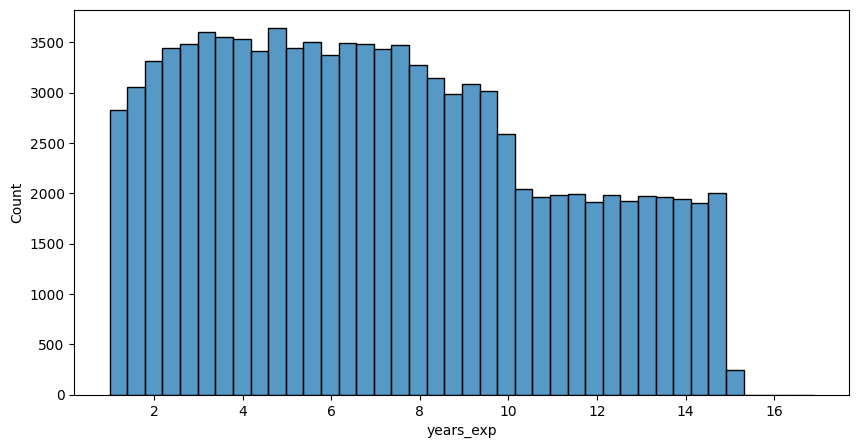

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(df["years_exp"],bins=40)

plt.show()

In [15]:
df['company'].value_counts().head(30)

,count
company,
Infosys,7590
Wayne Enterprises,7571
Wipro,7566
Initech,7528
Pied Piper,7500
Globex Inc,7492
Acme Corp,7490
Dunder Mifflin,7467
TCS,7451


In [16]:
df['country'].value_counts().head(20)

,count
country,
India,75113
USA,9978
Australia,2579
Canada,2506
UK,2472
Germany,2469
Singapore,2453
UAE,2430


In [17]:
signal_df=pd.DataFrame({
    "response_rate":[c["redrob_signals"]["recruiter_response_rate"] for c in candidates],

    "notice_period":[c["redrob_signals"]["notice_period_days"] for c in candidates],

    "github_score":[c["redrob_signals"]["github_activity_score"] for c in candidates],

    "open_to_work":[c["redrob_signals"]["open_to_work_flag"] for c in candidates],

    "interview_completion":[c["redrob_signals"]["interview_completion_rate"] for c in candidates],

    "saved_by_recruiters":[c["redrob_signals"]["saved_by_recruiters_30d"] for c in candidates]
})

In [18]:
signal_df.describe()

,response_rate,notice_period,github_score,interview_completion,saved_by_recruiters
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.436574,87.385800,9.619230,0.619510,7.658700
std,0.214122,36.589628,17.761394,0.170662,5.921436
min,0.020000,0.000000,-1.000000,0.300000,0.000000
25%,0.250000,60.000000,-1.000000,0.480000,3.000000
50%,0.440000,90.000000,-1.000000,0.620000,7.000000
75%,0.620000,120.000000,16.700000,0.760000,11.000000
max,0.950000,150.000000,96.900000,1.000000,80.000000


In [19]:
signal_df["notice_period"].value_counts()

,count
notice_period,
90,31097
60,24399
120,17570
30,13787
150,12981
45,144
15,18
0,4


In [20]:
signal_df["open_to_work"].value_counts()

,count
open_to_work,
False,64661
True,35339


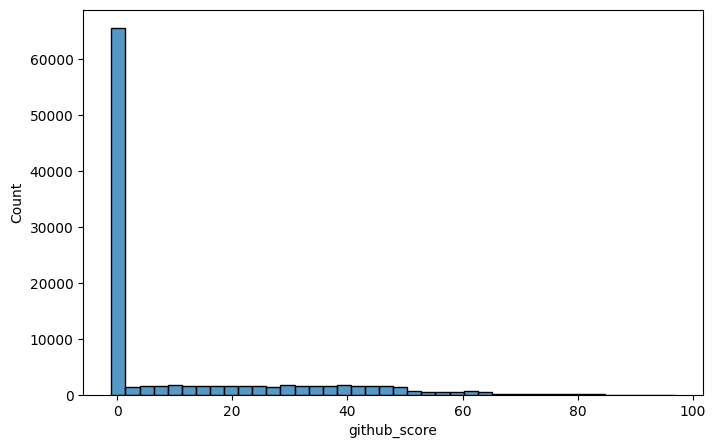

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(signal_df["github_score"],bins=40)

plt.show()

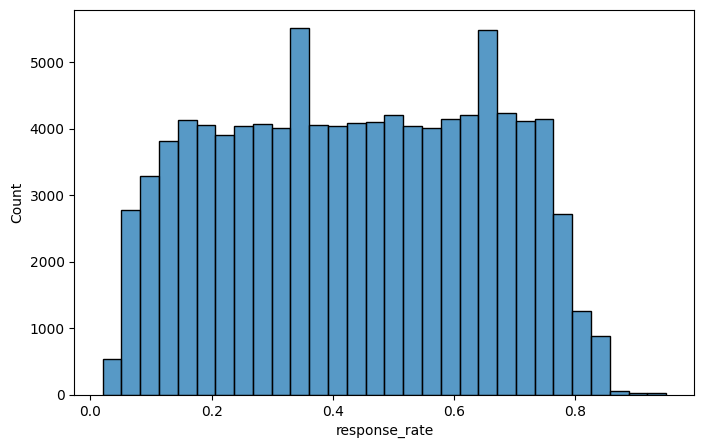

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(signal_df["response_rate"],bins=30)

plt.show()

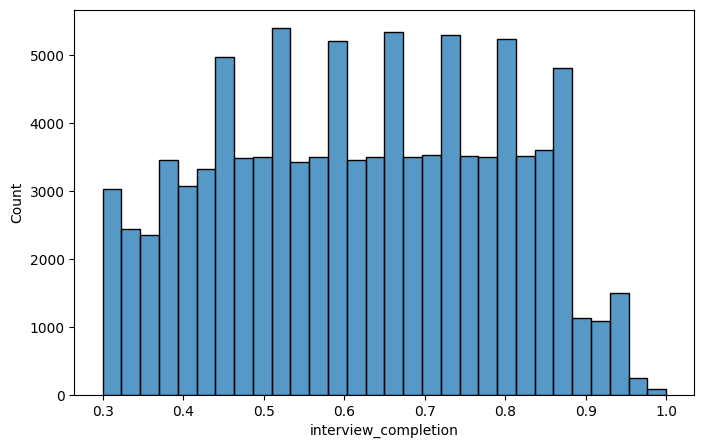

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(signal_df["interview_completion"],bins=30)

plt.show()

In [24]:
all_skills=[]

for c in candidates:
    for skill in c["skills"]:
        all_skills.append(skill["name"])

In [25]:
skill_series=pd.Series(all_skills)

skill_series.value_counts().head(50)

,count
HTML,12246
Databricks,12244
Redux,12222
Terraform,12187
Angular,12173
Salesforce CRM,12157
Figma,12157
Vue.js,12142
Sales,12138
Accounting,12136


In [26]:
skill_count=[]

for c in candidates:
    skill_count.append(len(c["skills"]))

pd.Series(skill_count).describe()

,0
count,100000.00000
mean,9.60302
std,3.31163
min,5.00000
25%,7.00000
50%,9.00000
75%,11.00000
max,23.00000


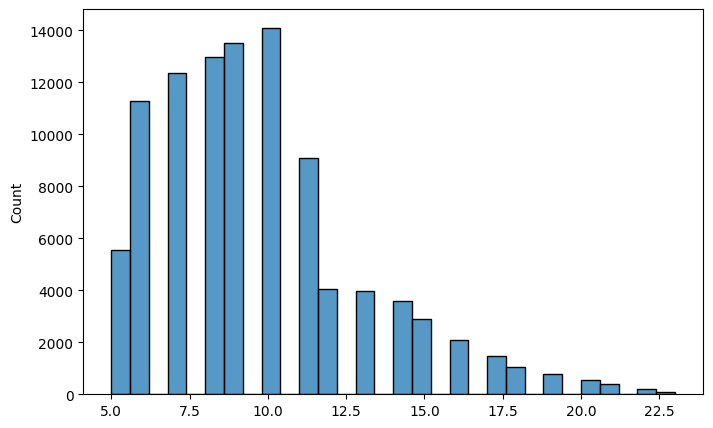

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(skill_count,bins=30)

plt.show()

In [28]:
num_jobs=[]

for c in candidates:
    num_jobs.append(len(c["career_history"]))

pd.Series(num_jobs).describe()

,0
count,100000.000000
mean,3.001710
std,1.522442
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,9.000000


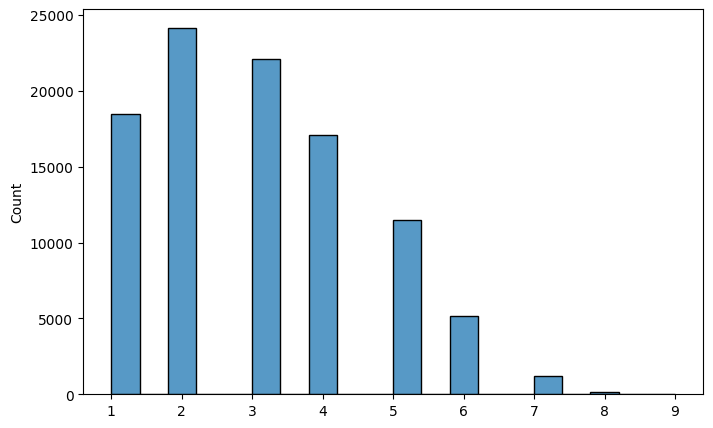

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(num_jobs,bins=20)
plt.show()

In [30]:
current_tenure=[]

for c in candidates:
    for job in c["career_history"]:
        if job["is_current"]:
            current_tenure.append(job["duration_months"])
            break

pd.Series(current_tenure).describe()

,0
count,100000.000000
mean,30.710620
std,12.022822
min,8.000000
25%,20.000000
50%,30.000000
75%,40.000000
max,228.000000


In [31]:
avg_duration=[]

for c in candidates:
    durations=[job["duration_months"] for job in c["career_history"]]

    avg_duration.append(np.mean(durations))

pd.Series(avg_duration).describe()

,0
count,100000.000000
mean,28.361075
std,7.819599
min,8.000000
25%,23.250000
50%,28.000000
75%,33.000000
max,98.000000


In [32]:
industry_counts=df["industry"].value_counts()

industry_counts.head(20)

,count
industry,
IT Services,29881
Software,22417
Manufacturing,22305
Conglomerate,7571
Paper Products,7467
Fintech,2808
Food Delivery,2514
E-commerce,1529
Consulting,1274


In [33]:
company_sizes=[]

for c in candidates:
    company_sizes.append(c["profile"]["current_company_size"])

pd.Series(company_sizes).value_counts()

,count
10001+,40464
1001-5000,18201
201-500,15096
51-200,7727
11-50,7568
501-1000,7525
5001-10000,3419


In [34]:
tiers=[]

for c in candidates:
    if len(c["education"])>0:
        tiers.append(c["education"][0]["tier"])

pd.Series(tiers).value_counts()

,count
tier_3,38047
tier_4,37235
tier_2,19853
tier_1,4865
